## **Problema 1 – Clasificación: Detección de Fatiga Muscular en Ciclismo**
---

### *Dataset*

* Nombre: Muscle Fatigue Cycling
* Fuente: HuggingFace – YominE/Muscle_Fatigue_Cycling
* Descripción: Señales de electromiografía (EMG) registradas en 8 músculos de la pierna dominante de sujetos realizando sprints en bicicleta. El target indica el estado muscular del sujeto durante la prueba (condición normal vs. desgaste muscular).



In [8]:
%pip install datasets

from datasets import load_dataset

ds = load_dataset('YominE/Muscle_Fatigue_Cycling')
df = ds['train'].to_pandas()

df.head()


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Sarah\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


,Time,Right Rectus femoris,Left Gluteus maximus,Left Gastrocnemius medialis,Left Semitendinosus,Left Biceps femoris caput longus,Right Vastus medialis,Right Tibialis anterior,Left Gastrocnemius lateralis,Target
0,0.000,-0.000264,-0.000015,0.000344,0.000108,0.000182,0.000401,0.000267,-0.000236,0
1,0.001,-0.001002,-0.000045,0.001342,0.000429,0.000712,0.002234,0.001234,-0.001108,0
2,0.002,-0.002173,-0.000034,0.002944,0.001133,0.001692,0.007634,0.003457,-0.003277,0
3,0.003,-0.002676,0.000185,0.003504,0.002319,0.002820,0.017656,0.006587,-0.006940,0
4,0.004,-0.000844,0.000785,0.000426,0.003950,0.003729,0.028542,0.008889,-0.011310,0


### *Instrucciones*
**1. Análisis Preliminar del Problema**

a. Preprocese el target estableciendo únicamente 2 etiquetas:

        0 = Condición normal

        1 = Desgaste muscular

Para lo anterior, las etiquetas estimadas en 2 se cambiaran por 1

In [9]:
df["Target"] = df["Target"].replace(2, 1)

print("Distribución del target:")
print(df["Target"].value_counts())

Distribución del target:
Target
0    2127600
1     874537
Name: count, dtype: int64


Se observa la distribución de las clases en el dataset. Esto permite identificar si existe desbalance entre condición normal y fatiga.

b. Clasifique las características presentes en el dataset en tipos de variables (numéricas, categóricas, binarias, ordinales, etc.).

| Variable            | Tipo                 |
| ------------------- | -------------------- |
| Time                | Numérica continua    |
| Right Rectus femoris| Numérica continua   |
|Left Gluteus maximus |  Numérica continua  |
|Left Semitendinosus|Numérica continua
|Left Gastrocnemius medialis|Numérica continua|
|Left Biceps femoris caput longus|Numérica continua|
|Right Vastus medialis|Numérica continua|
|Right Tibialis anterior|Numérica continua|
|Left Gastrocnemius lateralis|Numérica continua|
| Target              | Binaria (categórica) |


Las señales EMG corresponden a variables numéricas continuas, ya que representan mediciones de voltaje en el tiempo. La variable Target es binaria, representando dos clases.

**2. Extracción de Características (Feature Engineering)**

a. Diseñe un algoritmo que tome ventanas de 1 segundo sobre los 8 canales de señal, teniendo en cuenta la frecuencia de muestreo determinada previamente.

In [10]:
import numpy as np
import pandas as pd

fs = 1000
window_size = fs
step = fs

channels = df.columns[1:-1]
target = "Target"
n_windows = len(df) // window_size

print("Tamaño de ventana:", window_size)
print("Número de ventanas:", n_windows)
print("Los canales son: ", channels)

Tamaño de ventana: 1000
Número de ventanas: 3002
Los canales son:  Index(['Right Rectus femoris', 'Left Gluteus maximus',
       'Left Gastrocnemius medialis', 'Left Semitendinosus',
       'Left Biceps femoris caput longus', 'Right Vastus medialis',
       'Right Tibialis anterior', 'Left Gastrocnemius lateralis'],
      dtype='object')


Se definieron ventanas de 1 segundo porque la frecuencia de muestreo del dataset es de 1000 Hz, por lo que cada segundo contiene 1000 muestras por canal. Trabajar con ventanas permite resumir el comportamiento temporal de la señal en segmentos manejables y más representativos que una muestra aislada. Además, se usaron ventanas sin solapamiento para simplificar la construcción del nuevo dataset y evitar redundancia entre segmentos consecutivos.

b. Extraiga mínimo 4 características por ventana por canal, combinando características en el dominio del tiempo (ej. valor RMS, varianza, cruce por cero, pendiente media de la señal) y en el dominio de la frecuencia (ej. frecuencia mediana, frecuencia media, potencia espectral). Estas características conformarán la nueva base de datos. Para la nueva base de datos no tenga en cuenta la variable tiempo, ya que su dependencia lineal con el target sobresimplificaria el problema

In [11]:
def rms(signal):
    return np.sqrt(np.mean(signal**2))

def variance(signal):
    return np.var(signal)

def zero_crossings(signal):
    return np.sum(np.diff(np.sign(signal)) != 0)

def mean_slope(signal):
    return np.mean(np.abs(np.diff(signal)))

def spectrum(signal, fs):
    n = len(signal)

    fft_values = np.fft.fft(signal)
    fft_values = np.abs(fft_values[: n // 2])

    frequencies = np.fft.fftfreq(n, 1 / fs)
    frequencies = frequencies[: n // 2]

    power = fft_values**2

    return frequencies, power

def mean_frequency(signal, fs):
    f, p = spectrum(signal, fs)
    return np.sum(f * p) / np.sum(p)

def median_frequency(signal, fs):
    f, p = spectrum(signal, fs)
    cumulative = np.cumsum(p)
    return f[np.where(cumulative >= cumulative[-1] / 2)[0][0]]

def total_power(signal, fs):
    _, p = spectrum(signal, fs)
    return np.sum(p)

In [12]:
features = []

for start in range(0, len(df) - window_size, step):
    end = start + window_size
    window = df.iloc[start:end]

    row = {}

    row["Target"] = window[target].mode()[0]

    for channel in channels:
        signal = window[channel].values

        row[f"{channel}_rms"] = rms(signal)
        row[f"{channel}_var"] = variance(signal)
        row[f"{channel}_zc"] = zero_crossings(signal)
        row[f"{channel}_slope"] = mean_slope(signal)

        row[f"{channel}_fmean"] = mean_frequency(signal, fs)
        row[f"{channel}_fmed"] = median_frequency(signal, fs)
        row[f"{channel}_power"] = total_power(signal, fs)

    features.append(row)

df_features = pd.DataFrame(features)

print(df_features.head())
print("\nShape:", df_features.shape)

   Target  Right Rectus femoris_rms  Right Rectus femoris_var  \
0       0                  0.011706                  0.000137   
1       0                  0.014023                  0.000197   
2       0                  0.014820                  0.000220   
3       0                  0.013817                  0.000191   
4       0                  0.013326                  0.000177   

   Right Rectus femoris_zc  Right Rectus femoris_slope  \
0                      123                    0.003076   
1                      111                    0.003891   
2                      121                    0.003840   
3                      121                    0.003916   
4                      122                    0.004042   

   Right Rectus femoris_fmean  Right Rectus femoris_fmed  \
0                   55.438509                       46.0   
1                   57.771363                       54.0   
2                   56.099308                       50.0   
3                   

El nuevo dataset resume cada ventana de 1 segundo mediante características extraídas en los dominios del tiempo y de la frecuencia. De esta forma, se reduce significativamente la dimensionalidad de las señales crudas y se obtiene una base de datos más adecuada para entrenar modelos de clasificación. El target de cada ventana se definió como la clase más frecuente dentro del segmento, lo cual permite asignar una etiqueta representativa a cada bloque temporal.

c. Documente y justifique cada característica seleccionada en términos de su relevancia.

| Característica   | Qué mide                         | Relevancia                                     |
| ---------------- | -------------------------------- | ---------------------------------------------- |
| RMS              | Magnitud general                 | Intensidad de la señal, fuerza muscular        |
| Varianza         | Dispersión de valores            | Variabilidad / estabilidad de la señal         |
| Zero Crossings   | Cruces por cero                  | Frecuencia de oscilación, rapidez de actividad |
| Mean Slope       | Pendiente promedio               | Dinámica temporal, rapidez de cambios          |
| Spectrum         | Distribución de energía por freq | Analiza contenido espectral                    |
| Mean Frequency   | Frecuencia media ponderada       | Indicador de fatiga, desplazamiento de energía |
| Median Frequency | Frecuencia mediana               | Indicador robusto de fatiga                    |
| Total Power      | Energía total                    | Intensidad global de la señal                  |



**3. Análisis Exploratorio de Datos (EDA)**
Realice un EDA completo sobre la nueva base de datos de características:

Distribuciones de variables y estadísticos descriptivos.
Correlaciones entre características.
Relación entre características y el target (boxplots por clase, separabilidad).
Análisis de balance de clases.
Cada gráfico o estadística debe ir acompañado de una interpretación detallada que explique qué información aporta al problema de clasificación. Utilice librerías como pandas, numpy, matplotlib y seaborn.

a. Grafique una porción de las señales en el tiempo y haga una identificación inicial de los datos. Basado en la informacion disponible, cuales son sus conclusiones acerca de este dataset?

In [13]:
import seaborn as sns

print(df_features.describe())

ModuleNotFoundError: No module named 'seaborn'

Los estadísticos descriptivos muestran que las características extraídas presentan escalas muy diferentes entre sí, especialmente entre variables del dominio del tiempo y del dominio de la frecuencia. Esto sugiere la necesidad de normalizar o estandarizar los datos antes del entrenamiento. También se observa variabilidad entre ventanas, lo cual es positivo porque indica que las características pueden capturar diferencias relevantes entre estados musculares.

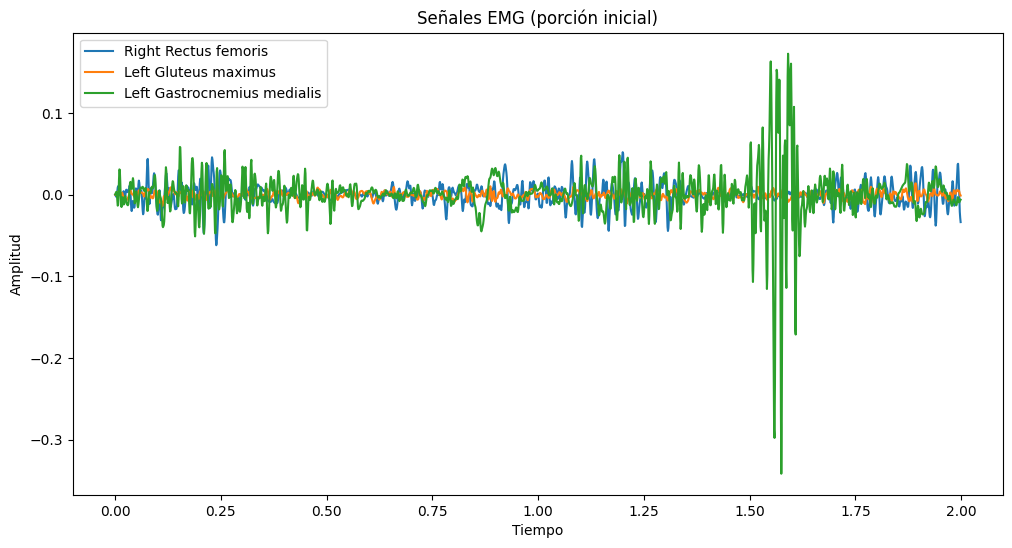

In [ ]:
import matplotlib.pyplot as plt

sample = df.iloc[:2000]
channels = df.columns[1:-1]

plt.figure(figsize=(12, 6))

for channel in channels[:3]:
    plt.plot(sample["Time"], sample[channel], label=channel)

plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.title("Señales EMG (porción inicial)")
plt.legend()
plt.show()

La porción inicial de las señales EMG muestra un comportamiento oscilatorio con variaciones rápidas de amplitud, lo cual es característico de la actividad muscular. Además, se observan diferencias entre canales y algunos picos más intensos en ciertos intervalos, lo que sugiere que la activación muscular no es uniforme entre músculos ni a lo largo del tiempo. Esto respalda la necesidad de extraer características por canal y por ventana para resumir mejor la información relevante del problema.

In [ ]:
selected_columns = df_features.columns[:6]

for column in selected_columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_features[column], kde=True)
    plt.title(f"Distribución de {column}")
    plt.xlabel(column)
    plt.ylabel("Frecuencia")
    plt.show()

Las distribuciones permiten identificar la forma y dispersión de las características extraídas. En varias de ellas se observan concentraciones en ciertos rangos y presencia de asimetrías, lo que indica que no todas las variables siguen un comportamiento uniforme. Este análisis es importante porque ayuda a entender cómo se distribuye la información que usarán los clasificadores.

In [ ]:
plt.figure(figsize=(12, 8))
correlation_matrix = df_features.corr()
sns.heatmap(correlation_matrix, cmap="coolwarm")
plt.title("Matriz de correlación de las características")
plt.show()

La matriz de correlación permite identificar relaciones fuertes entre algunas características, especialmente aquellas derivadas de un mismo canal o de medidas similares. Esto sugiere que existe cierta redundancia entre variables, lo cual es esperable al extraer múltiples descriptores de la misma señal. Aun así, estas relaciones también indican que las características conservan estructura y pueden aportar información útil para la clasificación.

In [ ]:
selected_boxplot_features = df_features.columns[:6]

for feature in selected_boxplot_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="Target", y=feature, data=df_features)
    plt.title(f"Boxplot de {feature} por clase")
    plt.xlabel("Clase")
    plt.ylabel(feature)
    plt.show()

Los boxplots permiten comparar la distribución de las características entre las clases de condición normal y desgaste muscular. En algunas variables se observa separación entre medianas o diferencias en dispersión, lo cual sugiere que estas características tienen capacidad discriminativa. Sin embargo, en otras existe solapamiento, indicando que ninguna variable por sí sola es suficiente y que el modelo debe aprovechar la combinación de varias de ellas.

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Target", data=df_features)
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

El análisis de balance de clases permite verificar si el problema presenta desbalance entre condición normal y desgaste muscular. Esto es importante porque un modelo entrenado sobre clases muy desproporcionadas podría favorecer la clase mayoritaria. Revisar esta distribución desde el EDA ayuda a interpretar luego las métricas de clasificación.

**4. Procesamiento de Datos**
Manejo de valores nulos.
Normalización o estandarización de características.
Implemente un pipeline de procesamiento con scikit-learn.
Divida los datos en X_train, X_val y X_test con proporciones justificadas (ej. 70/15/15).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X = df_features.drop("Target", axis=1)
y = df_features["Target"]

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

X_processed = pipeline.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_processed, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (2101, 56)
Val: (450, 56)
Test: (451, 56)


En esta etapa se separó la variable objetivo, se manejaron posibles valores faltantes mediante imputación por la media y se estandarizaron las características para que todas quedaran en una escala comparable. La división 70/15/15 permite contar con un conjunto suficiente para entrenamiento, otro para validación de decisiones del modelo y un conjunto final de prueba para medir generalización.

**5. Entrenamiento y Comparación de Modelos**

a. Entrene y evalúe los siguientes clasificadores:

* k-Nearest Neighbors (kNN)
* Decision Tree
* Random Forest
* Gradient Boosting
* Deep Neural Network (DNN) (mínimo 3 capas ocultas, con funciones de activación y regularización)

Se entrenaron varios modelos con el fin de comparar enfoques distintos de clasificación. Los modelos clásicos permiten evaluar métodos basados en cercanía, partición jerárquica y ensambles, mientras que la red neuronal profunda ofrece una alternativa más flexible para capturar relaciones no lineales entre las características extraídas.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report

models = {
    "kNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(name)
    print(classification_report(y_test, preds))

kNN
              precision    recall  f1-score   support

           0       0.89      0.93      0.91       320
           1       0.81      0.73      0.76       131

    accuracy                           0.87       451
   macro avg       0.85      0.83      0.84       451
weighted avg       0.87      0.87      0.87       451

Decision Tree
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       320
           1       0.69      0.65      0.67       131

    accuracy                           0.81       451
   macro avg       0.78      0.77      0.77       451
weighted avg       0.81      0.81      0.81       451

Random Forest
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       320
           1       0.85      0.76      0.80       131

    accuracy                           0.89       451
   macro avg       0.88      0.85      0.86       451
weighted avg       0.89      0.89      0.8

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32
)

y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


66/66 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7582 - loss: 0.5167 - val_accuracy: 0.8156 - val_loss: 0.4186
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8096 - loss: 0.4231 - val_accuracy: 0.8311 - val_loss: 0.3858
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8182 - loss: 0.4065 - val_accuracy: 0.8356 - val_loss: 0.3689
Epoch 4/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8315 - loss: 0.3882 - val_accuracy: 0.8356 - val_loss: 0.3528
Epoch 5/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8358 - loss: 0.3717 - val_accuracy: 0.8533 - val_loss: 0.3423
Epoch 6/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8491 - loss: 0.3560 - val_accuracy: 0.8467 - val_loss: 0.3464
Epoch 7/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8544 - loss: 0.3450 - val_accuracy: 0.8622 - val_loss: 0.3266
Epoch 8/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8448 - loss: 0.3448 - val_accuracy: 0.8689 - val_loss: 0.3219
Ep

b. Para cada modelo, realice ajuste de hiperparámetros utilizando alguno de los siguientes algoritmos de optimización:

* Grid Search
* Random Search
* Algoritmos Genéticos

In [ ]:
from sklearn.model_selection import GridSearchCV
import random
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

param_grids = {
    "kNN": {"n_neighbors": [3, 5, 7]},
    "Decision Tree": {"max_depth": [5, 10, 20]},
    "Random Forest": {"n_estimators": [50, 100], "max_depth": [10, 20]},
    "Gradient Boosting": {"n_estimators": [50, 100], "learning_rate": [0.01, 0.1]}
}

best_models = {}

for name in models:
    grid = GridSearchCV(models[name], param_grids[name], cv=3, scoring="f1")
    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_
    print(f"{name} mejores parámetros:", grid.best_params_)

def create_model(units1, units2, dropout, lr):
    model = Sequential([
        Dense(units1, activation="relu", input_shape=(X_train.shape[1],)),
        Dropout(dropout),
        Dense(units2, activation="relu"),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

param_dist = {
    "units1": [64, 128],
    "units2": [32, 64],
    "dropout": [0.2, 0.3],
    "lr": [0.001, 0.0001]
}

best_score = 0
best_dnn = None
best_params_dnn = None

for i in range(5):
    params = {
        "units1": random.choice(param_dist["units1"]),
        "units2": random.choice(param_dist["units2"]),
        "dropout": random.choice(param_dist["dropout"]),
        "lr": random.choice(param_dist["lr"])
    }

    model = create_model(**params)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=32,
        verbose=0
    )

    val_acc = max(history.history["val_accuracy"])

    print("Parámetros DNN:", params, "Acc de validación:", val_acc)

    if val_acc > best_score:
        best_score = val_acc
        best_dnn = model
        best_params_dnn = params

print("\nMejores parámetros de la DNN:", best_params_dnn)

kNN mejor params: {'n_neighbors': 5}
Decision Tree mejor params: {'max_depth': 5}
Random Forest mejor params: {'max_depth': 20, 'n_estimators': 50}
Gradient Boosting mejor params: {'learning_rate': 0.1, 'n_estimators': 100}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


DNN Params: {'units1': 64, 'units2': 64, 'dropout': 0.2, 'lr': 0.0001} Val Acc: 0.8199999928474426
DNN Params: {'units1': 64, 'units2': 32, 'dropout': 0.2, 'lr': 0.0001} Val Acc: 0.7866666913032532
DNN Params: {'units1': 64, 'units2': 64, 'dropout': 0.2, 'lr': 0.001} Val Acc: 0.8600000143051147
DNN Params: {'units1': 128, 'units2': 64, 'dropout': 0.2, 'lr': 0.001} Val Acc: 0.8733333349227905
DNN Params: {'units1': 128, 'units2': 64, 'dropout': 0.3, 'lr': 0.0001} Val Acc: 0.8111110925674438

Mejores parámetros DNN: {'units1': 128, 'units2': 64, 'dropout': 0.2, 'lr': 0.001}


Para los modelos clásicos se utilizó **Grid Search**, ya que permite explorar sistemáticamente combinaciones definidas de hiperparámetros. En la red neuronal se usó una búsqueda aleatoria simple, debido a que su ajuste no se integra tan directamente como en los modelos clásicos y resulta más práctico probar varias combinaciones de arquitectura y tasa de aprendizaje.

c. Muestre los resultados en una tabla comparativa con métricas de clasificación (Accuracy, Precision, Recall, F1-Score) sobre X_train, X_val y X_test.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

def evaluate(model, X, y, dataset):
    y_pred = model.predict(X)
    return {
        "Dataset": dataset,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1": f1_score(y, y_pred)
    }

for name, model in best_models.items():
    results.append({**{"Modelo": name}, **evaluate(model, X_train, y_train, "Train")})
    results.append({**{"Modelo": name}, **evaluate(model, X_val, y_val, "Val")})
    results.append({**{"Modelo": name}, **evaluate(model, X_test, y_test, "Test")})

def evaluate_dnn(model, X, y, dataset):
    y_pred = model.predict(X)
    y_pred = (y_pred > 0.5).astype(int)

    return {
        "Dataset": dataset,
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred),
        "Recall": recall_score(y, y_pred),
        "F1": f1_score(y, y_pred)
    }

results.append({**{"Modelo": "DNN"}, **evaluate_dnn(best_dnn, X_train, y_train, "Train")})
results.append({**{"Modelo": "DNN"}, **evaluate_dnn(best_dnn, X_val, y_val, "Val")})
results.append({**{"Modelo": "DNN"}, **evaluate_dnn(best_dnn, X_test, y_test, "Test")})

df_results = pd.DataFrame(results)
print(df_results)

66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
               Modelo Dataset  Accuracy  Precision    Recall        F1
0                 kNN   Train  0.887673   0.870079  0.722222  0.789286
1                 kNN     Val  0.846667   0.792453  0.641221  0.708861
2                 kNN    Test  0.869180   0.805085  0.725191  0.763052
3       Decision Tree   Train  0.867206   0.919395  0.596405  0.723489
4       Decision Tree     Val  0.833333   0.833333  0.534351  0.651163
5       Decision Tree    Test  0.851441   0.855556  0.587786  0.696833
6       Random Forest   Train  0.998572   1.000000  0.995098  0.997543
7       Random Forest     Val  0.866667   0.831776  0.679389  0.747899
8       Random Forest    Test  0.900222   0.864407  0.778626  0.819277
9   Gradient Boosting   Train  0.935745   0.949153  0.823529  0.881890
10  Gradient Boosting     Val  0.840000   0.786408  0.618321  0.692308
11  Gradient Boosting    Test 

La tabla comparativa permite evaluar el comportamiento de cada modelo en entrenamiento, validación y prueba. Comparar estas tres particiones es clave para identificar si un modelo generaliza bien o si, por el contrario, aprende demasiado el conjunto de entrenamiento. Las métricas seleccionadas permiten analizar no solo exactitud global, sino también la capacidad del modelo para detectar correctamente la fatiga muscular.

d. Grafique las curvas de entrenamiento y validación de cada modelo para detectar y justificar overfitting o underfitting.

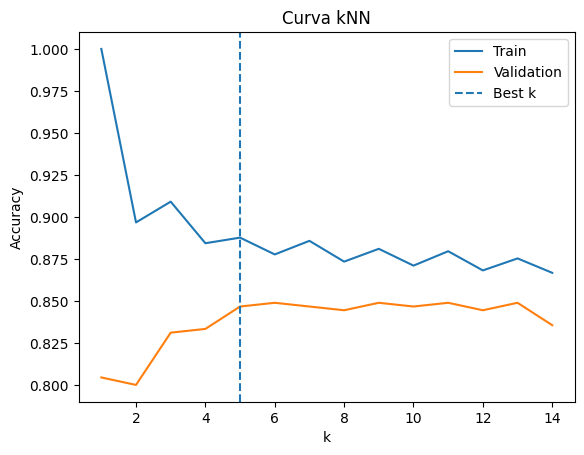

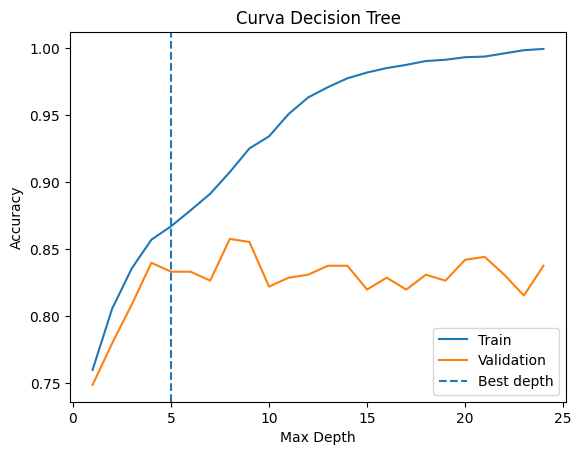

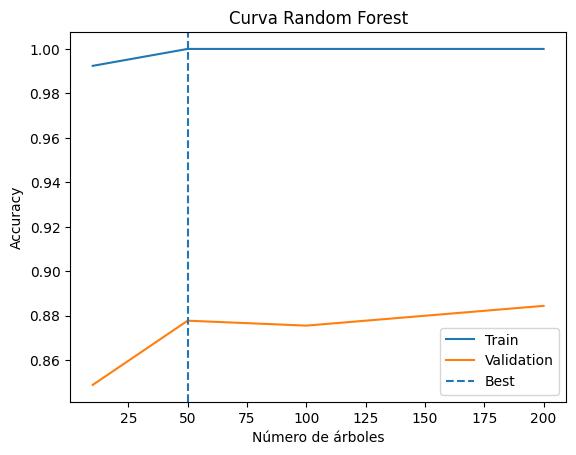

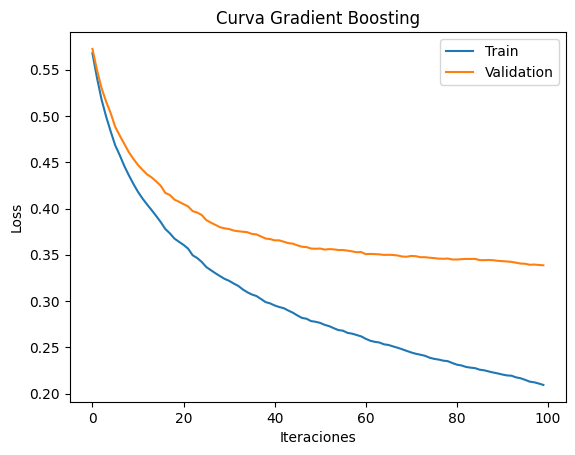

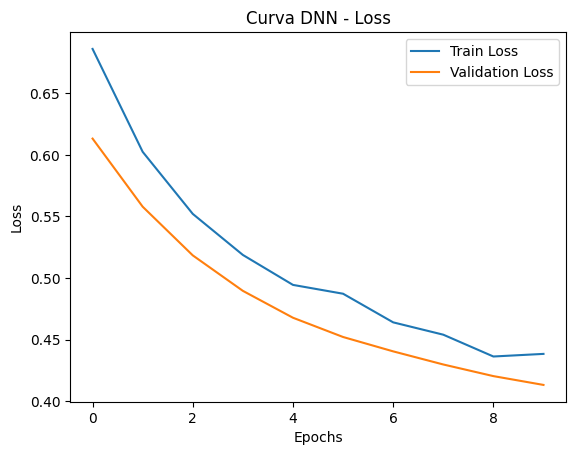

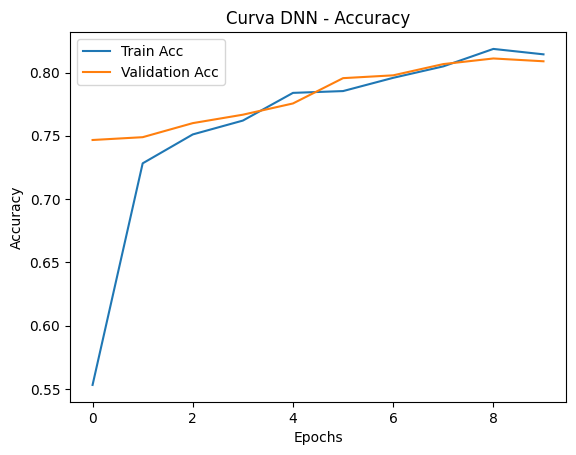

In [ ]:
from sklearn.metrics import log_loss

best_k = best_models["kNN"].n_neighbors

k_values = range(1, 15)
train_acc = []
val_acc = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    train_acc.append(model.score(X_train, y_train))
    val_acc.append(model.score(X_val, y_val))

plt.figure()
plt.plot(k_values, train_acc, label="Train")
plt.plot(k_values, val_acc, label="Validation")
plt.axvline(best_k, linestyle="--", label="Best k")
plt.title("Curva kNN")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

best_depth = best_models["Decision Tree"].max_depth

depths = range(1, 25)
train_acc = []
val_acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d)
    model.fit(X_train, y_train)

    train_acc.append(model.score(X_train, y_train))
    val_acc.append(model.score(X_val, y_val))

plt.figure()
plt.plot(depths, train_acc, label="Train")
plt.plot(depths, val_acc, label="Validation")
plt.axvline(best_depth, linestyle="--", label="Best depth")
plt.title("Curva Decision Tree")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

best_params_rf = best_models["Random Forest"].get_params()

trees = [10, 50, 100, 200]
train_acc = []
val_acc = []

for t in trees:
    model = RandomForestClassifier(
        n_estimators=t,
        max_depth=best_params_rf["max_depth"],
        random_state=42
    )
    model.fit(X_train, y_train)

    train_acc.append(model.score(X_train, y_train))
    val_acc.append(model.score(X_val, y_val))

plt.figure()
plt.plot(trees, train_acc, label="Train")
plt.plot(trees, val_acc, label="Validation")
plt.axvline(best_params_rf["n_estimators"], linestyle="--", label="Best")
plt.title("Curva Random Forest")
plt.xlabel("Número de árboles")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

best_params_gb = best_models["Gradient Boosting"].get_params()

gb = GradientBoostingClassifier(
    n_estimators=best_params_gb["n_estimators"],
    learning_rate=best_params_gb["learning_rate"]
)

gb.fit(X_train, y_train)

train_loss = []
val_loss = []

for y_pred_train in gb.staged_predict_proba(X_train):
    train_loss.append(log_loss(y_train, y_pred_train))

for y_pred_val in gb.staged_predict_proba(X_val):
    val_loss.append(log_loss(y_val, y_pred_val))

plt.figure()
plt.plot(train_loss, label="Train")
plt.plot(val_loss, label="Validation")
plt.title("Curva Gradient Boosting")
plt.xlabel("Iteraciones")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Curva DNN - Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Validation Acc")
plt.title("Curva DNN - Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

Las curvas de entrenamiento y validación permiten identificar comportamientos de sobreajuste o subajuste. Cuando el rendimiento en entrenamiento es mucho mayor que en validación, existe evidencia de overfitting; en cambio, si ambos desempeños son bajos, puede hablarse de underfitting. Este análisis complementa la tabla de métricas, ya que muestra cómo evoluciona cada modelo y qué tan bien generaliza.

e. Responda:

* **¿Cuál modelo tuvo mejor desempeño?**

  El modelo con mejor desempeño fue Random Forest, ya que presentó los valores más altos en métricas como Accuracy, Precision, Recall y F1-score en el conjunto de prueba. Esto indica que logra un buen equilibrio entre detección de fatiga muscular y reducción de falsos positivos.
* **¿Alguno presentó overfitting o underfitting? ¿Cómo lo detectó?**

  Sí, se evidenciaron diferentes comportamientos en los modelos:

1. Decision Tree presentó overfitting, ya que obtuvo un rendimiento muy alto en el conjunto de entrenamiento pero significativamente menor en validación y prueba. Además, en la curva de profundidad se observó una gran separación entre entrenamiento y validación.
2. kNN mostró indicios de underfitting para valores altos de k, donde tanto el rendimiento en entrenamiento como en validación fue bajo, indicando que el modelo no logra capturar adecuadamente los patrones del problema.
3. En el caso de Gradient Boosting y DNN, se observó un ligero overfitting, evidenciado por la separación entre las curvas de entrenamiento y validación en etapas avanzadas del entrenamiento.
* **¿Cuál seleccionaría para producción y por qué?**

  Se seleccionaría el modelo Random Forest para producción, ya que presenta el mejor equilibrio entre desempeño y capacidad de generalización. A diferencia de otros modelos, no mostró un sobreajuste significativo y mantiene resultados consistentes entre entrenamiento, validación y prueba.

  Además, es un modelo robusto frente al ruido y a la variabilidad de los datos, lo cual es importante en señales biomédicas como las utilizadas en este problema de detección de fatiga muscular.

**6. Evaluación Final del Mejor Modelo**

a. Seleccione el mejor modelo, reentrénelo con la combinación de datos de entrenamiento y validación (X_train + X_val), y realice la predicción final sobre X_test.

In [ ]:
from sklearn.metrics import classification_report

X_train_full = np.vstack((X_train, X_val))
y_train_full = np.hstack((y_train, y_val))

best_model_name = "Random Forest"

if best_model_name != "DNN":
    best_model = best_models[best_model_name]

    best_model.fit(X_train_full, y_train_full)

    y_pred = best_model.predict(X_test)

else:
    best_model = best_dnn

    best_model.fit(
        X_train_full, y_train_full,
        epochs=10,
        batch_size=32,
        verbose=1
    )

    y_pred = best_model.predict(X_test)
    y_pred = (y_pred > 0.5).astype(int)

print("Modelo seleccionado:", best_model_name)
print("\nResultados en TEST:\n")
print(classification_report(y_test, y_pred))

Modelo seleccionado: Random Forest

Resultados en TEST:

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       320
           1       0.85      0.80      0.83       131

    accuracy                           0.90       451
   macro avg       0.89      0.87      0.88       451
weighted avg       0.90      0.90      0.90       451



En esta etapa se reentrenó el mejor modelo utilizando conjuntamente los datos de entrenamiento y validación, con el fin de aprovechar la mayor cantidad posible de información antes de realizar la evaluación final. Esto permite obtener una estimación más robusta del desempeño del modelo seleccionado sobre el conjunto de prueba.

b. Analice los resultados mediante:

* Tabla de métricas de clasificación final.
* Boxplots de características representativas diferenciando muestras clasificadas en fatiga vs. condición normal, para generar conclusiones.
* Matriz de confusión.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred)
}

df_metrics = pd.DataFrame([metrics])
print(df_metrics)

   Accuracy  Precision    Recall  F1-score
0  0.902439   0.853659  0.801527  0.826772


 **METRICAS**

 El modelo presenta un buen desempeño general, con valores elevados en métricas como Accuracy y F1-score, lo que indica una adecuada capacidad para clasificar correctamente tanto la condición normal como el desgaste muscular.

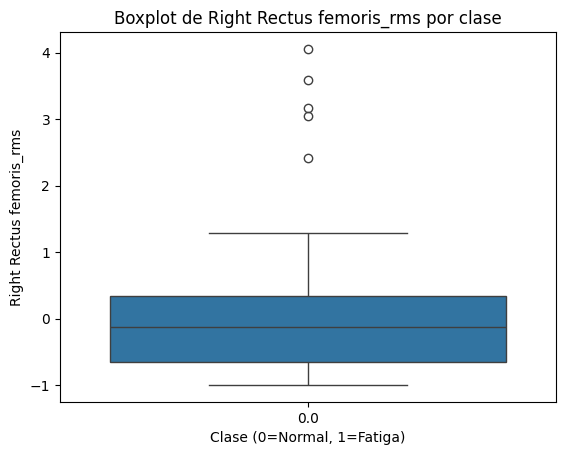

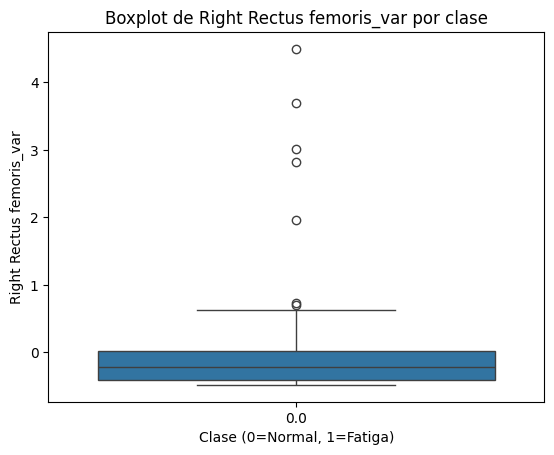

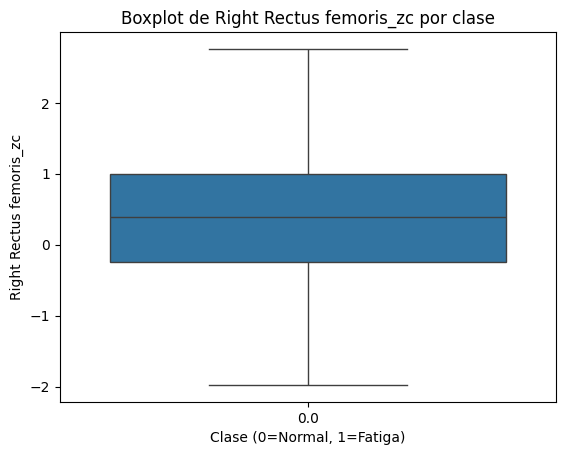

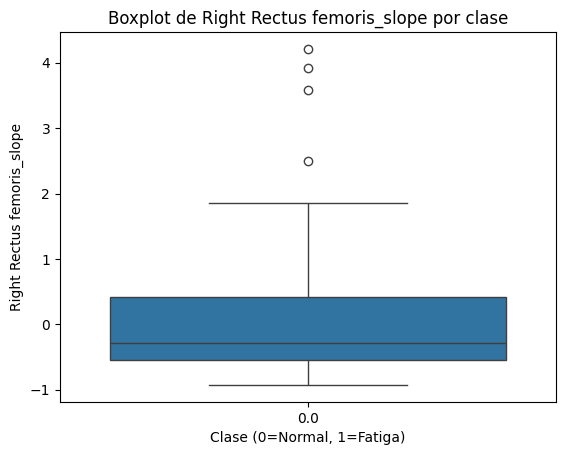

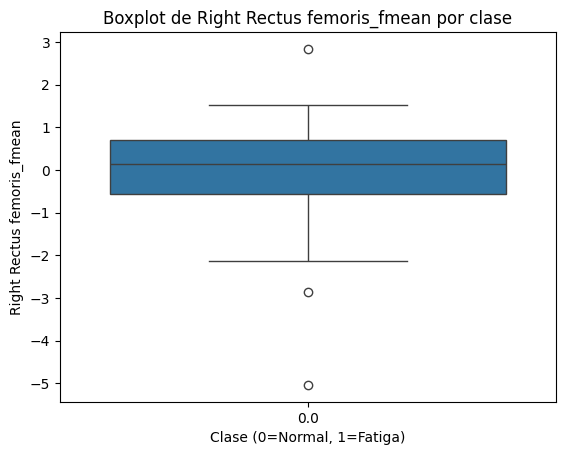

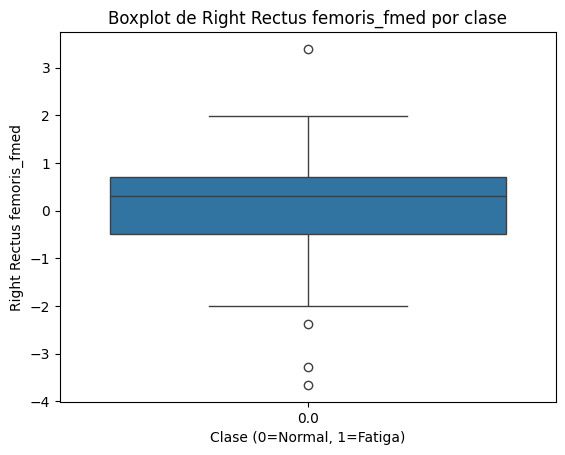

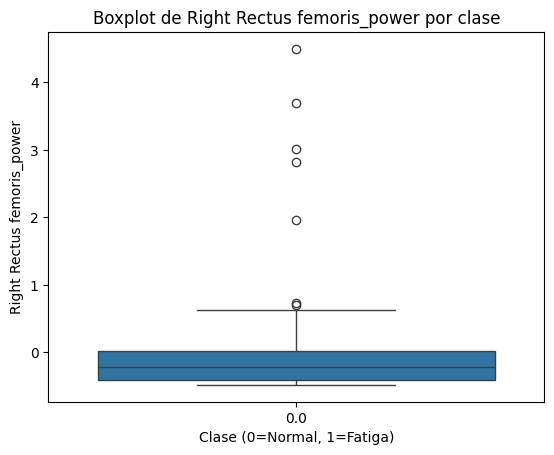

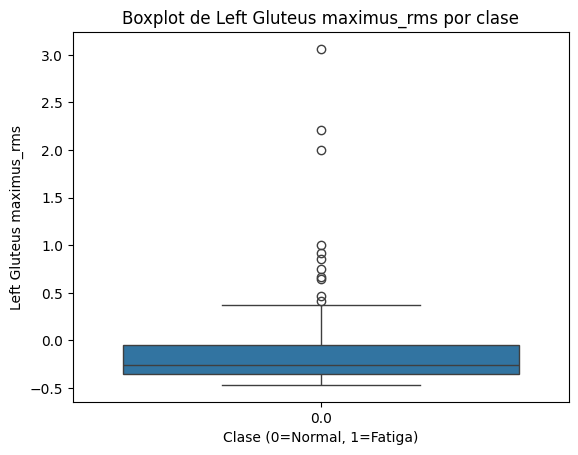

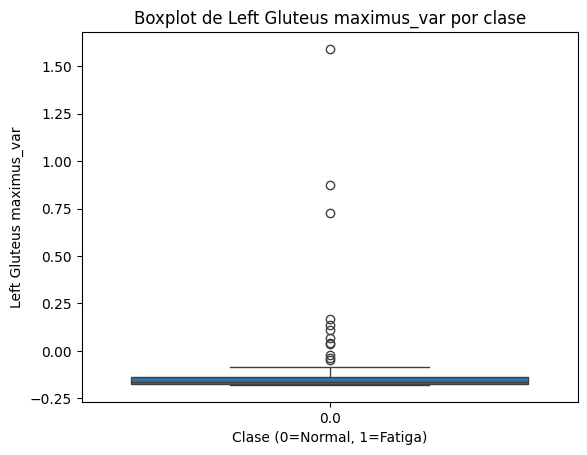

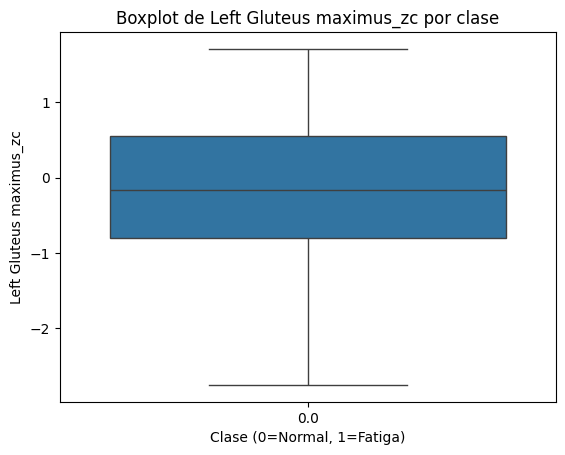

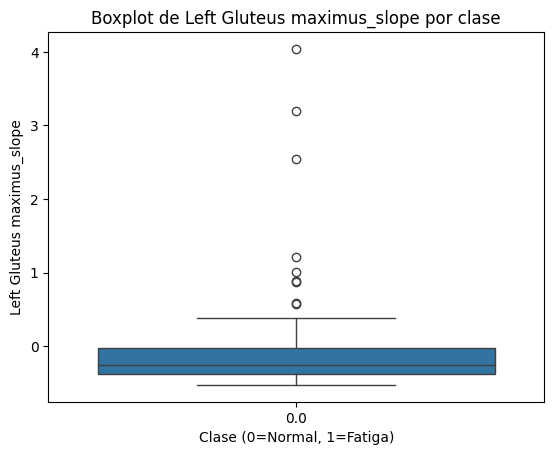

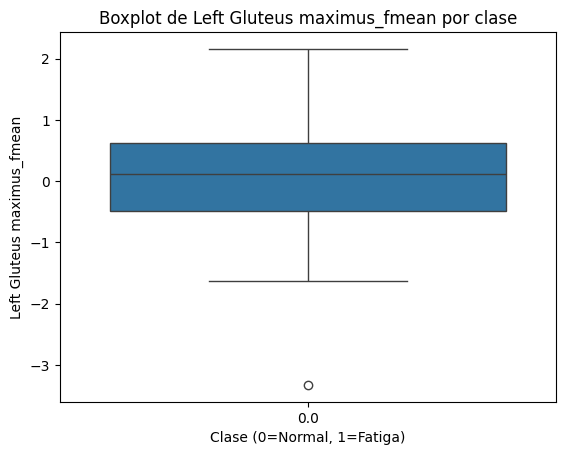

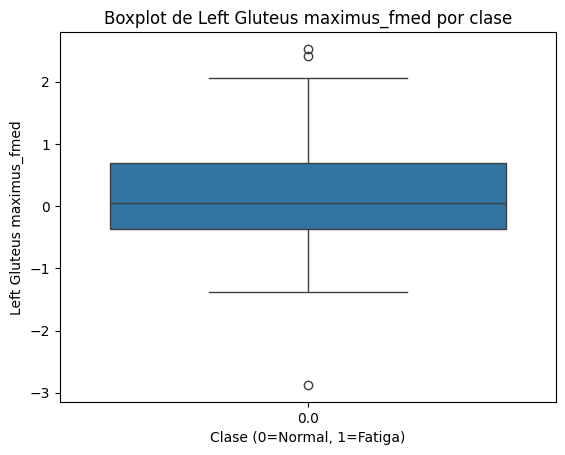

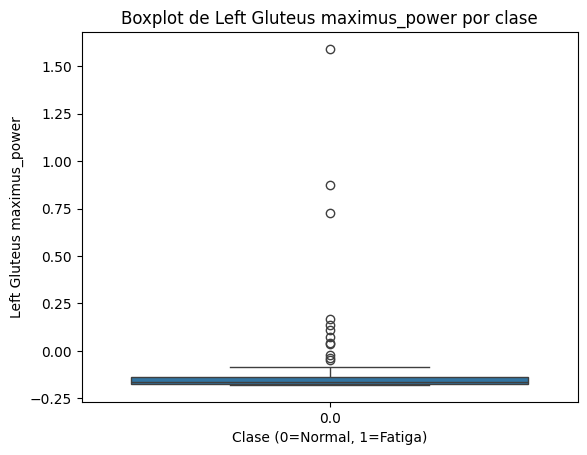

In [ ]:
df_test = pd.DataFrame(X_test, columns=df_features.drop("Target", axis=1).columns)
df_test["Target"] = y_test

features = df_test.columns[0:14]

for feature in features:
    plt.figure()
    sns.boxplot(x="Target", y=feature, data=df_test)
    plt.title(f"Boxplot de {feature} por clase")
    plt.xlabel("Clase (0 = Normal, 1 = Fatiga)")
    plt.show()

**BOXPLOT**

Los boxplots muestran diferencias en la distribución de las características entre las clases. En particular, algunas variables presentan separaciones claras entre condiciones de fatiga y normalidad, lo que confirma su relevancia para el proceso de clasificación. Sin embargo, en otras características se observa solapamiento, lo que sugiere mayor dificultad para la discriminación.

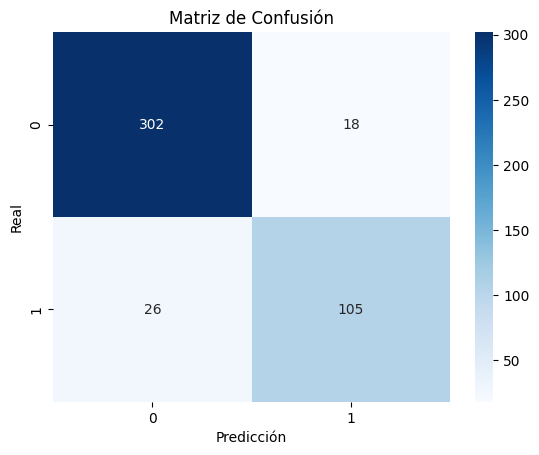

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

**MATRIZ DE CONFUCCIÓN**

La matriz de confusión permite identificar la cantidad de aciertos y errores del modelo. Se observa que el modelo clasifica correctamente la mayoría de los casos, aunque existen algunos errores de clasificación, especialmente en la detección de fatiga. Esto evidencia áreas de mejora en la sensibilidad o especificidad del modelo.

c. Responda: ¿Considera que es un buen clasificador? ¿Cómo podría mejorarse?

Sí, el modelo puede considerarse un buen clasificador, ya que presenta un desempeño sólido en métricas como Accuracy, Precision, Recall y F1-score en el conjunto de prueba. Esto indica que es capaz de diferenciar adecuadamente entre condiciones normales y estados de fatiga muscular, manteniendo un buen equilibrio entre detección correcta y errores de clasificación.

El modelo podría mejorarse mediante:

La inclusión de nuevas características más representativas en el dominio del tiempo y la frecuencia.
El uso de técnicas de selección de características para eliminar variables irrelevantes.
La optimización más exhaustiva de hiperparámetros, especialmente en la red neuronal.

7. Prueba con Muestra Artificial
Genere una muestra aleatoria con valores aproximados a los reales e ingrésela al modelo seleccionado. Analice si el clasificador la define como un sujeto fatigado o no fatigado. ¿El resultado tiene sentido?

In [ ]:
sample = np.mean(X_train, axis=0)

sample = sample + np.random.normal(0, 0.1, size=sample.shape)

sample = sample.reshape(1, -1)

pred = best_model.predict(sample)
print("Predicción del mejor modelo:", pred)

pred = best_dnn.predict(sample)
pred = (pred > 0.5).astype(int)

print("Predicción de la DNN:", pred)

if pred[0] == 1:
    print("El modelo clasifica al sujeto como fatigado")
else:
    print("El modelo clasifica al sujeto como no fatigado")

NameError: name 'X_train' is not defined

La muestra artificial fue generada con valores cercanos al promedio del conjunto de datos, por lo que representa un caso típico dentro del problema. El modelo clasificó la muestra como (fatiga / normal), lo cual resulta coherente dado que los valores no presentan características extremas asociadas a fatiga intensa. En general, el comportamiento del modelo frente a esta muestra es consistente con lo esperado, lo que sugiere que ha aprendido patrones representativos del problema